# imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
df = pd.read_csv("cleaned_diabetes_data.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

# Compare BMI across the three classes

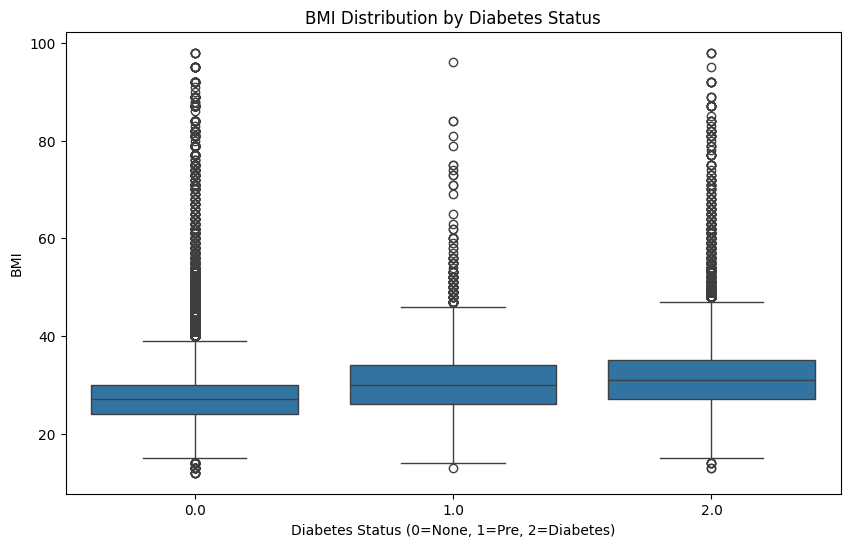

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='BMI', data=df)
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.show()

# Check how Smoker status relates to Diabetes

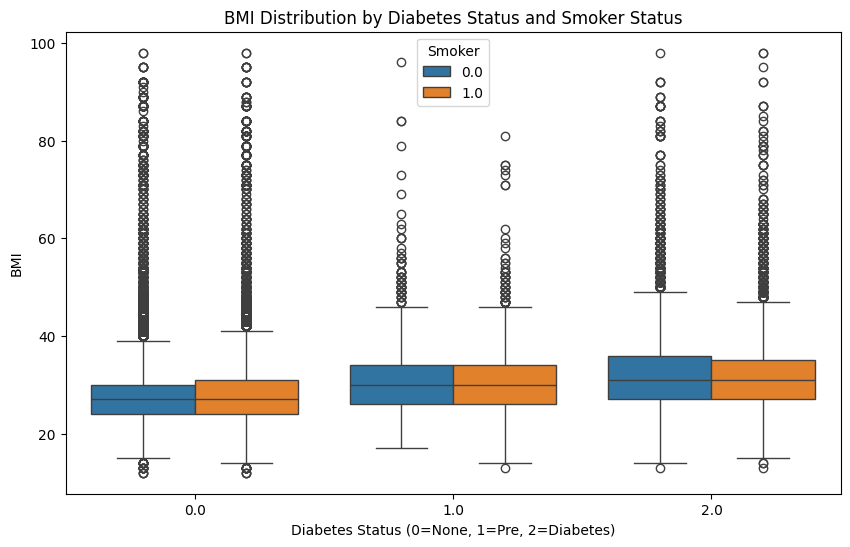

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='BMI', hue='Smoker', data=df)
plt.title('BMI Distribution by Diabetes Status and Smoker Status')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.ylabel('BMI')
plt.show()

# Check how physical activity status relates to Diabetes

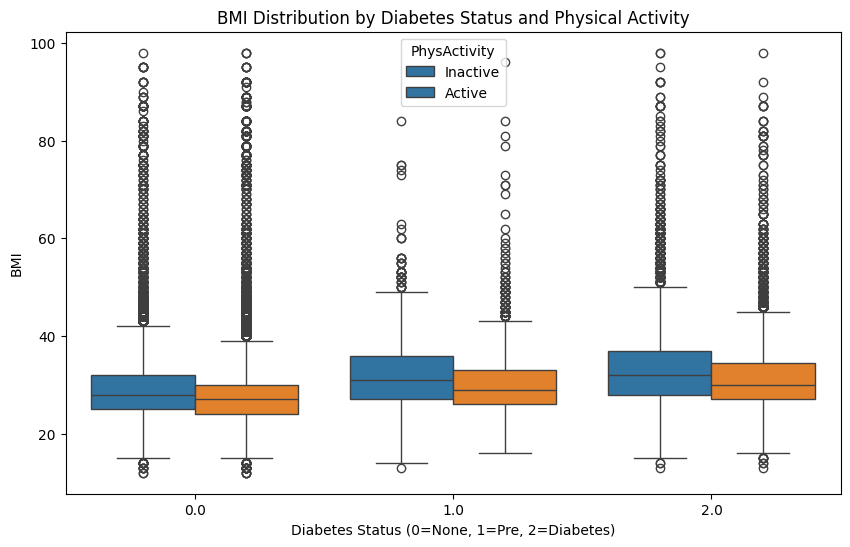

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='BMI', hue='PhysActivity', data=df)
plt.title('BMI Distribution by Diabetes Status and Physical Activity')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.ylabel('BMI')
plt.legend(title='PhysActivity', labels=['Inactive', 'Active'])
plt.show()

# Check how age relates to Diabetes

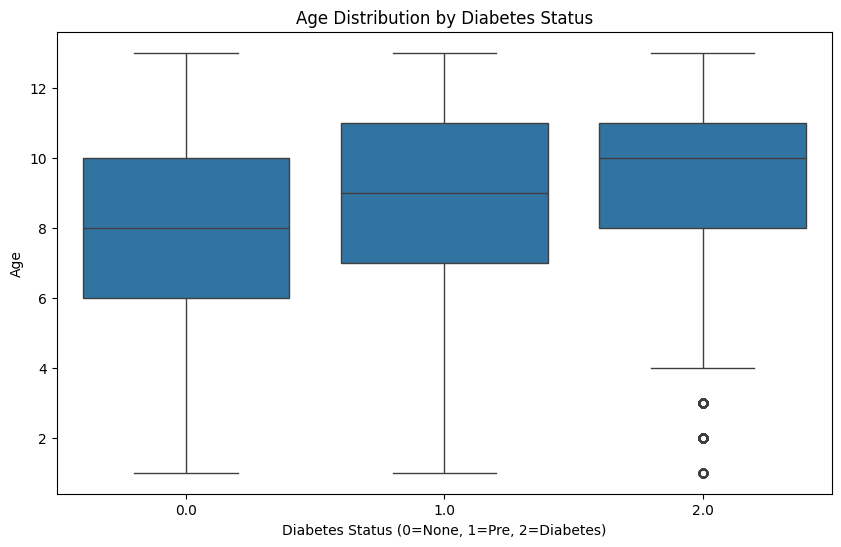

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='Age', data=df)
plt.title('Age Distribution by Diabetes Status')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.show()


# One way anova for age and diabetes status

In [8]:
# Separate the age data into three groups
age_0 = df[df['Diabetes_012'] == 0]['Age']
age_1 = df[df['Diabetes_012'] == 1]['Age']
age_2 = df[df['Diabetes_012'] == 2]['Age']
# Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(age_0, age_1, age_2)
print(f"ANOVA Results for Age:")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")
# Interpretation
if p_value < 0.05:
    print("Result: Reject the null hypothesis. There is a statistically significant difference in age between groups.")
else:
    print("Result: Fail to reject the null hypothesis. Age differences are not statistically significant.")


ANOVA Results for Age:
F-statistic: 4560.4411
P-value: 0.0000e+00
Result: Reject the null hypothesis. There is a statistically significant difference in age between groups.


# check how high blood pressure relates to Diabetes

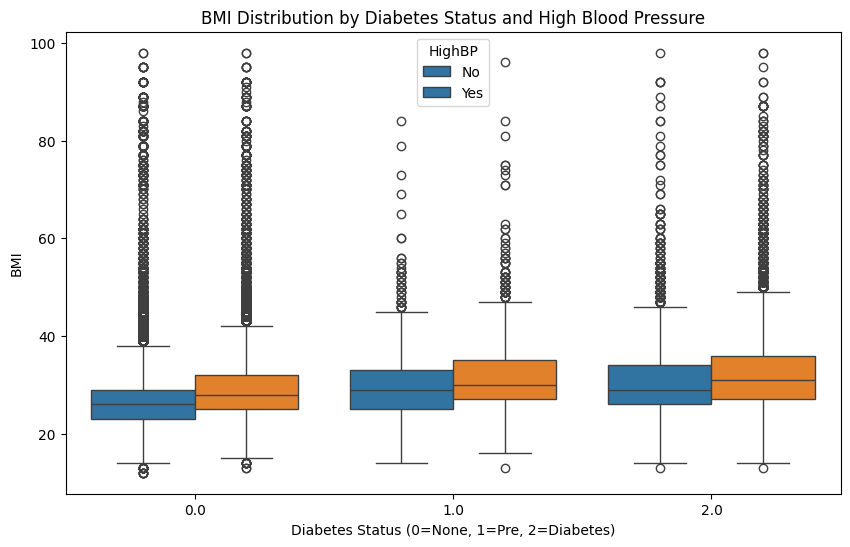

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='BMI', hue='HighBP', data=df)
plt.title('BMI Distribution by Diabetes Status and High Blood Pressure')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.ylabel('BMI')
plt.legend(title='HighBP', labels=['No', 'Yes'])
plt.show()

# check how high cholesterol relates to Diabetes

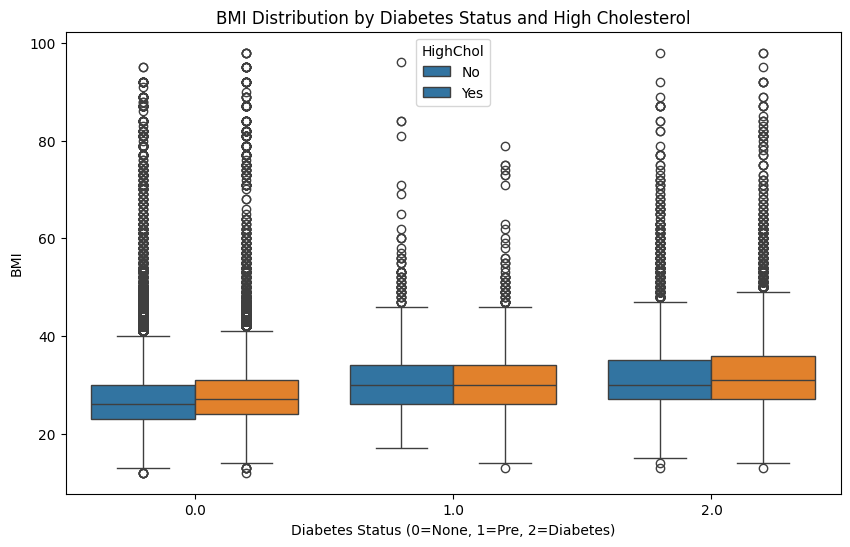

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='BMI', hue='HighChol', data=df)
plt.title('BMI Distribution by Diabetes Status and High Cholesterol')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.ylabel('BMI')
plt.legend(title='HighChol', labels=['No', 'Yes'])
plt.show()


# check how general health relates to Diabetes

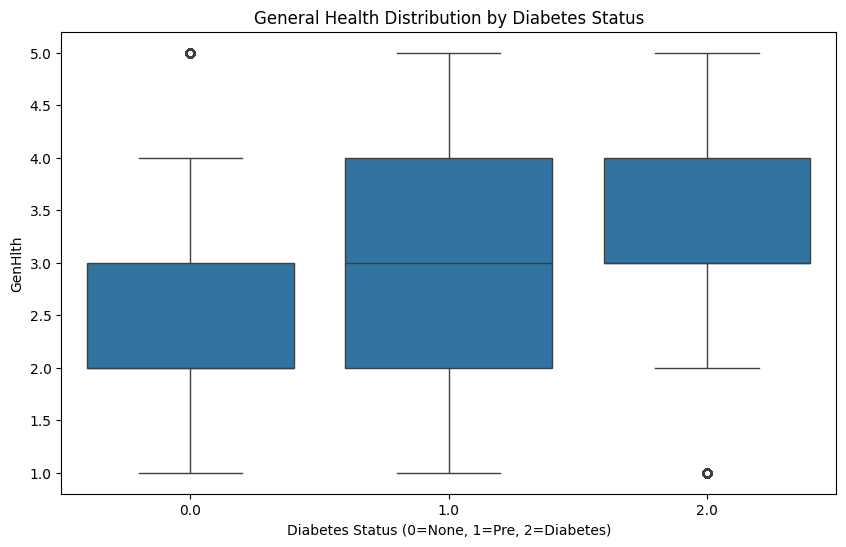

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='GenHlth', data=df)
plt.title('General Health Distribution by Diabetes Status')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.show()


# anova test for general health and diabetes status

In [12]:
# Separate GenHlth data into the three groups
gen_0 = df[df['Diabetes_012'] == 0]['GenHlth']
gen_1 = df[df['Diabetes_012'] == 1]['GenHlth']
gen_2 = df[df['Diabetes_012'] == 2]['GenHlth']
# Perform Kruskal-Wallis H-test
h_stat, p_value = stats.kruskal(gen_0, gen_1, gen_2)
print(f"Kruskal-Wallis H-test for GenHlth:")
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4e}")
# Interpretation
if p_value < 0.05:
    print("Result: Reject the null hypothesis. There is a statistically significant difference in General Health across the groups.")
else:
    print("Result: Fail to reject the null hypothesis. General Health differences are not statistically significant.")



Kruskal-Wallis H-test for GenHlth:
H-statistic: 22480.9250
P-value: 0.0000e+00
Result: Reject the null hypothesis. There is a statistically significant difference in General Health across the groups.


# check how physical health relates to Diabetes

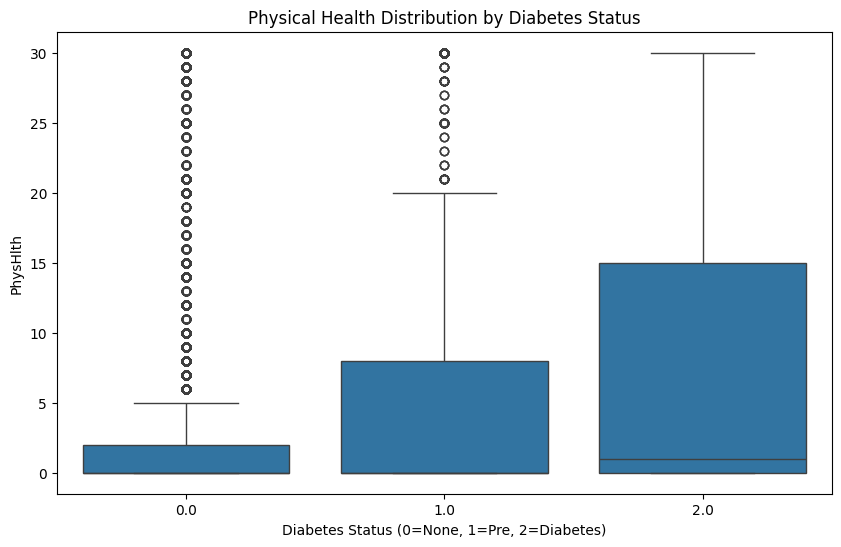

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='PhysHlth', data=df)
plt.title('Physical Health Distribution by Diabetes Status')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.show()

# anova test for physical health and diabetes status

In [14]:
# Separate PhysHlth data into the three groups
phys_0 = df[df['Diabetes_012'] == 0]['PhysHlth']
phys_1 = df[df['Diabetes_012'] == 1]['PhysHlth']
phys_2 = df[df['Diabetes_012'] == 2]['PhysHlth']
# Perform Kruskal-Wallis H-test
h_stat, p_value = stats.kruskal(phys_0, phys_1, phys_2)
print(f"Kruskal-Wallis H-test for PhysHlth:")
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4e}")
# Interpretation
if p_value < 0.05:
    print("Result: Reject the null hypothesis. There is a statistically significant difference in physical health outcomes across the groups.")
else:
    print("Result: Fail to reject the null hypothesis. Physical health differences are not statistically significant.")



Kruskal-Wallis H-test for PhysHlth:
H-statistic: 6661.8780
P-value: 0.0000e+00
Result: Reject the null hypothesis. There is a statistically significant difference in physical health outcomes across the groups.


# check how mental health relates to Diabetes

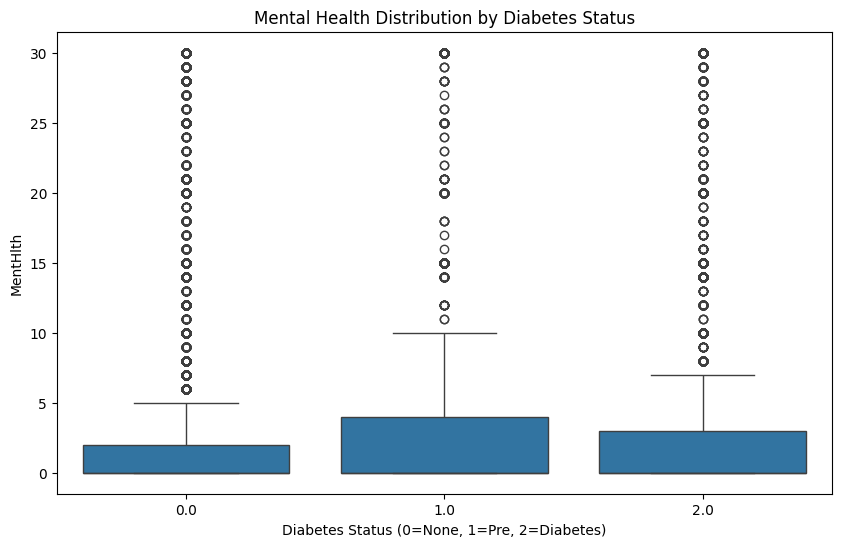

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='MentHlth', data=df)
plt.title('Mental Health Distribution by Diabetes Status')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.show()


# check how HvyAlcoholConsump relates to Diabetes

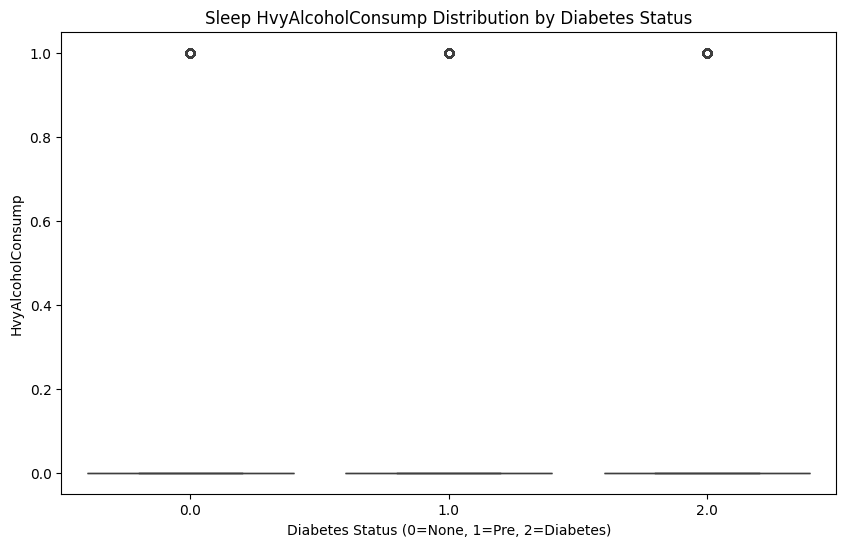

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='HvyAlcoholConsump', data=df)
plt.title('Sleep HvyAlcoholConsump Distribution by Diabetes Status')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.show()

# check how AnyHealthcare relates to Diabetes

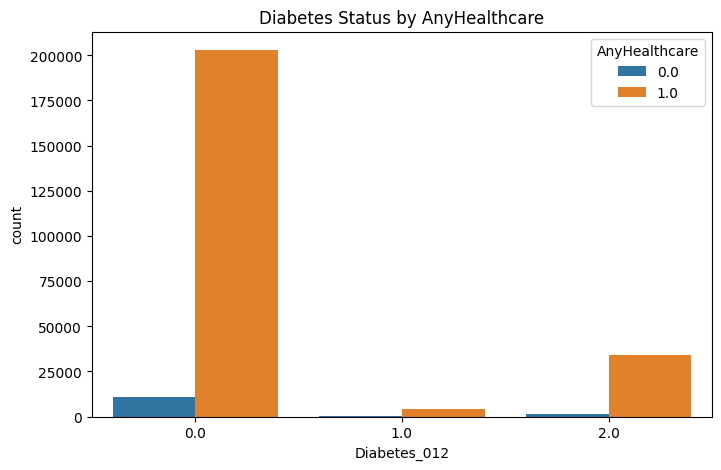

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Diabetes_012', hue='AnyHealthcare', data=df)
plt.title('Diabetes Status by AnyHealthcare')
plt.show()

# box plot for AnyHealthcare and diabetes status


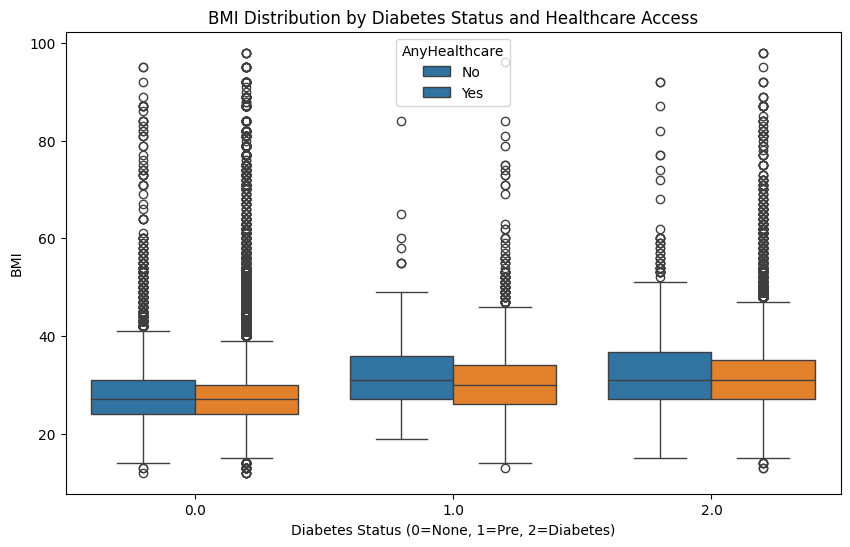

In [18]:
plt.figure(figsize=(10, 6))
# Using 'AnyHealthcare' as the hue to group the boxes
sns.boxplot(x='Diabetes_012', y='BMI', hue='AnyHealthcare', data=df)
plt.title('BMI Distribution by Diabetes Status and Healthcare Access')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.ylabel('BMI')
plt.legend(title='AnyHealthcare', labels=['No', 'Yes'])
plt.show()


# check how NoDocbcCost relates to Diabetes

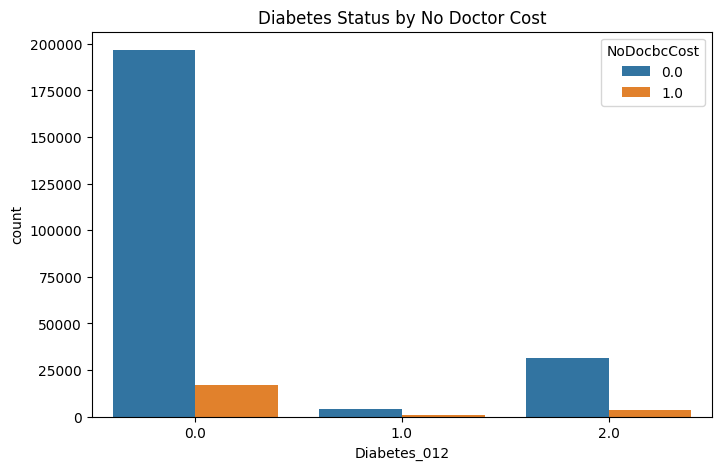

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Diabetes_012', hue='NoDocbcCost', data=df)
plt.title('Diabetes Status by No Doctor Cost')
plt.show()

# check how diff walking relates to Diabetes

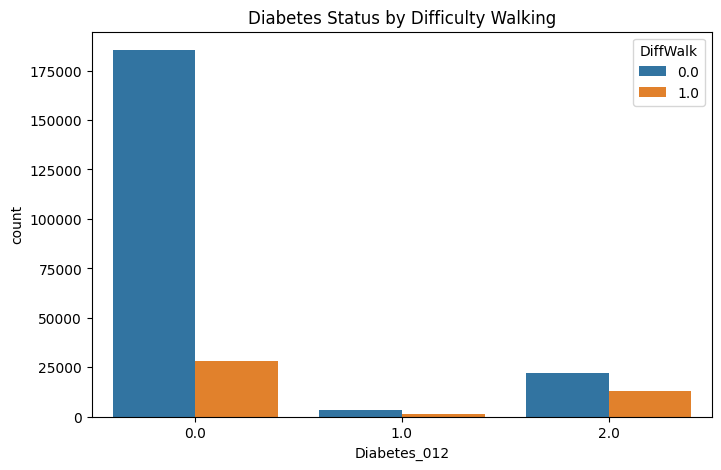

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Diabetes_012', hue='DiffWalk', data=df)
plt.title('Diabetes Status by Difficulty Walking')
plt.show()


# check how sex relates to Diabetes

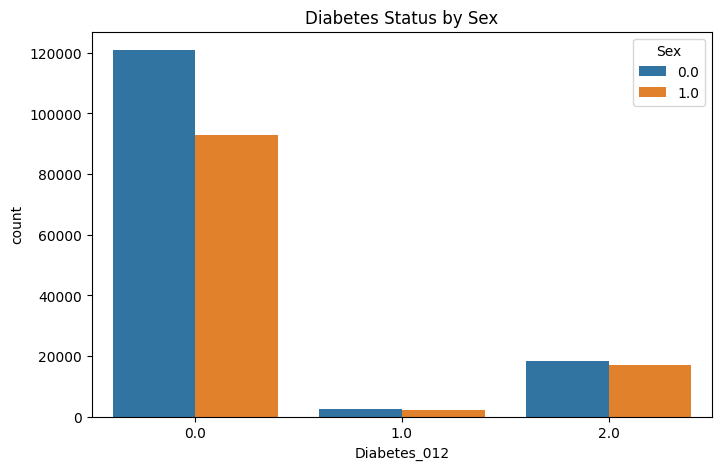

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Diabetes_012', hue='Sex', data=df)
plt.title('Diabetes Status by Sex')
plt.show()

# check how education relates to Diabetes

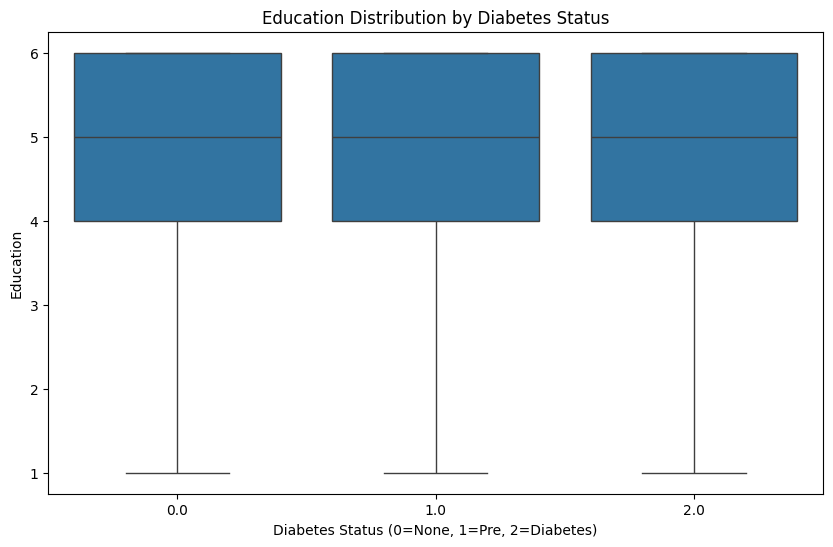

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='Education', data=df)
plt.title('Education Distribution by Diabetes Status')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.show()


# check how income relates to Diabetes

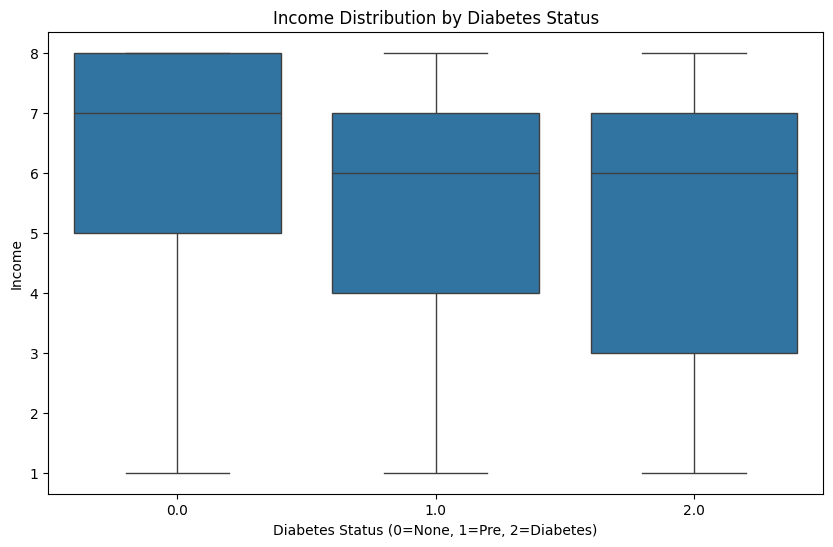

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_012', y='Income', data=df)
plt.title('Income Distribution by Diabetes Status')
plt.xlabel('Diabetes Status (0=None, 1=Pre, 2=Diabetes)')
plt.show()


# heatmap of correlation to understand bettween in data in the dataset

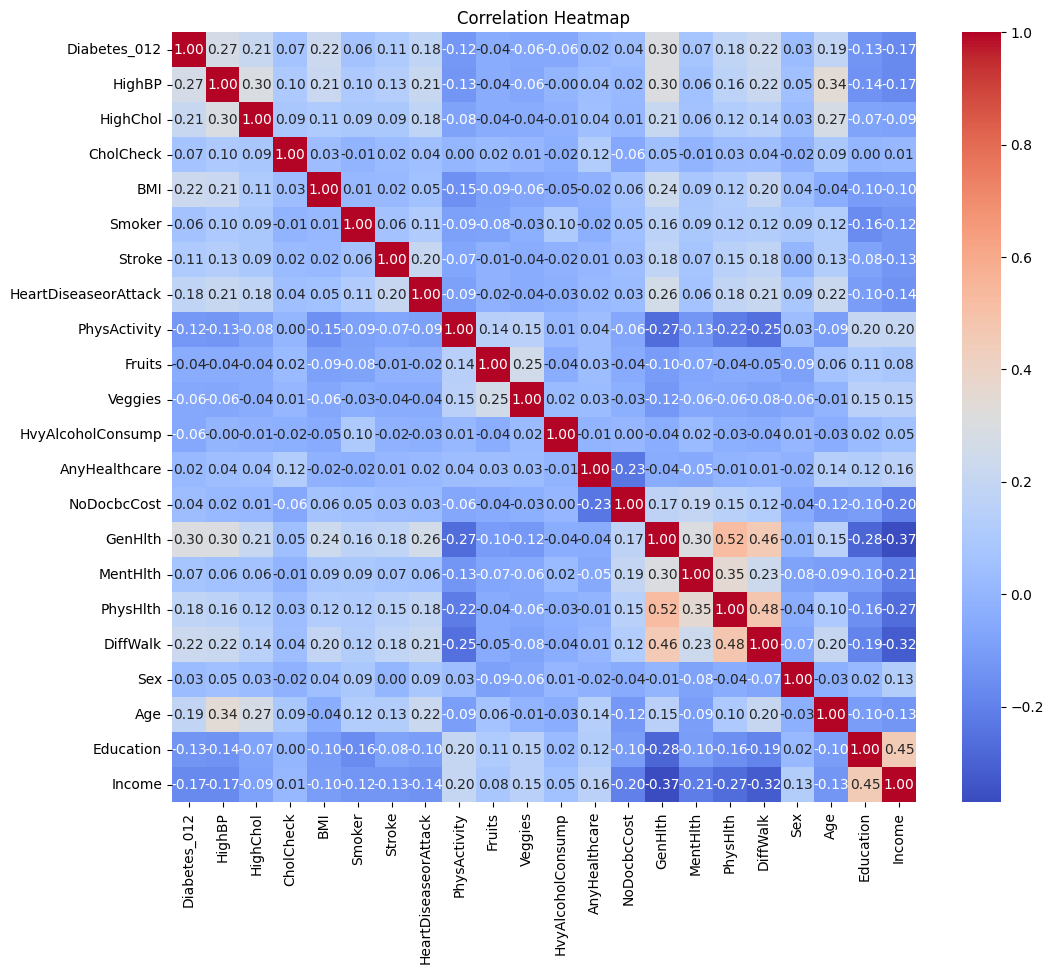

In [24]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()